In [54]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import spikingjelly
from spikingjelly.activation_based import neuron, functional, surrogate

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import joblib
import os

# ── Reproducibility ───────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# os.makedirs("../outputs", exist_ok=True)

print(f"PyTorch      : {torch.__version__}")
# print(f"SpikingJelly : {spikingjelly.__version__}")
print(f"Device       : {DEVICE}")
print("✅ Imports done")

PyTorch      : 2.10.0+cpu
Device       : cpu
✅ Imports done


#### Load train and val CSVs

In [55]:
train_raw = pd.read_csv("../data/processed/train_features.csv",
                         index_col=0, parse_dates=True)
val_raw   = pd.read_csv("../data/processed/val_features.csv",
                         index_col=0, parse_dates=True)

train_raw.index.name='date'
val_raw.index.name='date'

# ── Feature and target columns ────────────────────────────────────────
TARGET_COL   = "target"
FEATURE_COLS = [c for c in train_raw.columns if c != TARGET_COL]

print(f"Train rows    : {len(train_raw)}")
print(f"Val rows      : {len(val_raw)}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target        : '{TARGET_COL}'")

# ── Drop rows where ANY feature or target is NaN ──────────────────────
train_clean = train_raw[FEATURE_COLS + [TARGET_COL]].dropna()
val_clean   = val_raw[FEATURE_COLS + [TARGET_COL]].dropna()

print(f"\nAfter dropna:")
print(f"  Train : {len(train_clean)} rows  (dropped {len(train_raw)-len(train_clean)})")
print(f"  Val   : {len(val_clean)} rows  (dropped {len(val_raw)-len(val_clean)})")
print(f"\nTarget balance:")
print(f"  Train up-days : {train_clean[TARGET_COL].mean()*100:.1f}%")
print(f"  Val   up-days : {val_clean[TARGET_COL].mean()*100:.1f}%")

Train rows    : 1093
Val rows      : 364
Features (9): ['daily_return', 'log_return', 'rolling_mean_7d', 'rolling_std_7d', 'price_momentum_5d', 'spike_signal', 'spike_intensity', 'inter_spike_interval', 'india_repo_rate']
Target        : 'target'

After dropna:
  Train : 1088 rows  (dropped 5)
  Val   : 364 rows  (dropped 0)

Target balance:
  Train up-days : 35.9%
  Val   up-days : 39.3%


#### Normalize features (train only fit)

In [56]:
# ── Rule: fit scaler on TRAIN only, transform all splits ─────────────
# Fitting on val/test would leak their distribution into the model.
# The scaler must only "know" what the training data looks like.

scaler = MinMaxScaler(feature_range=(0, 1), clip=True)

# Fit + transform train
X_train_raw = train_clean[FEATURE_COLS].values.astype(np.float32)
y_train     = train_clean[TARGET_COL].values.astype(np.float32)

X_train_norm = scaler.fit_transform(X_train_raw)   # ← fit happens HERE only

# Transform val using the SAME fitted scaler
X_val_raw   = val_clean[FEATURE_COLS].values.astype(np.float32)
y_val       = val_clean[TARGET_COL].values.astype(np.float32)

X_val_norm  = scaler.transform(X_val_raw)           # ← no fit, just transform

# ── Save scaler for FastAPI use in Month 2 ───────────────────────────
scaler_path = "../outputs/scaler.pkl"  
joblib.dump(scaler, scaler_path)     # joblib is used for FastAPI 

print("=== NORMALISATION SUMMARY ===")
print(f"  Train shape    : {X_train_norm.shape}")
print(f"  Val shape      : {X_val_norm.shape}")
print(f"  Train range    : [{X_train_norm.min():.4f}, {X_train_norm.max():.4f}]")
print(f"  Val range      : [{X_val_norm.min():.4f}, {X_val_norm.max():.4f}]")
print(f"  Scaler saved   : {scaler_path}")

# Val may slightly exceed [0,1] if val has values outside train range
# This is expected and correct — do NOT refit the scaler
val_outside = ((X_val_norm < 0) | (X_val_norm > 1)).sum()
print(f"  Val values outside [0,1]: {val_outside}  "
      f"({'expected — train range not universal' if val_outside > 0 else '✅ all in range'})")

=== NORMALISATION SUMMARY ===
  Train shape    : (1088, 9)
  Val shape      : (364, 9)
  Train range    : [0.0000, 1.0000]
  Val range      : [0.0000, 1.0000]
  Scaler saved   : ../outputs/scaler.pkl
  Val values outside [0,1]: 0  (✅ all in range)


#### Diagonistic check for Val_outside

In [57]:
# Overall outside ratio
outside_mask = (X_val_norm < 0) | (X_val_norm > 1)
outside_ratio = outside_mask.mean()
print(f"Overall outside ratio: {outside_ratio:.2%}")
print(f"Global val range after scaling: [{X_val_norm.min():.4f}, {X_val_norm.max():.4f}]")

# Per-feature diagnostics
for i, col in enumerate(FEATURE_COLS):
    col_vals = X_val_norm[:, i]
    col_out = ((col_vals < 0) | (col_vals > 1)).mean()
    print(f"{col:20s} outside={col_out:7.2%}  min={col_vals.min():8.4f}  max={col_vals.max():8.4f}")

Overall outside ratio: 0.00%
Global val range after scaling: [0.0000, 1.0000]
daily_return         outside=  0.00%  min=  0.3290  max=  0.6388
log_return           outside=  0.00%  min=  0.3341  max=  0.6441
rolling_mean_7d      outside=  0.00%  min=  0.2515  max=  0.6491
rolling_std_7d       outside=  0.00%  min=  0.0000  max=  0.5212
price_momentum_5d    outside=  0.00%  min=  0.3445  max=  0.7779
spike_signal         outside=  0.00%  min=  0.0000  max=  1.0000
spike_intensity      outside=  0.00%  min=  0.0000  max=  0.3371
inter_spike_interval outside=  0.00%  min=  0.0000  max=  1.0000
india_repo_rate      outside=  0.00%  min=  0.4030  max=  0.7164


#### TimeSeriesDataset class

In [58]:
class TimeSeriesDataset(Dataset):
    """
    PyTorch Dataset for sliding-window time series sequences.

    Converts a flat (rows, features) array into sequences of shape
    (lookback, n_features) for each valid prediction timestep.

    No shuffling should be applied to the DataLoader using this
    dataset — time order must be preserved for temporal validity.

    Parameters
    ----------
    features : np.ndarray, shape (n_rows, n_features)
        Normalised feature matrix. Must be float32.
    targets : np.ndarray, shape (n_rows,)
        Binary target array (0 or 1). Must be float32.
    lookback : int, default 10
        how many past timesteps you want to include in each training sample.
        X[t] = features[t-lookback : t]
        y[t] = targets[t]

    Returns (from __getitem__)
    --------------------------
    sequence : torch.Tensor, shape (lookback, n_features)
    label    : torch.Tensor, scalar float32 (0.0 or 1.0)
    """

    def __init__(self,
                 features : np.ndarray,
                 targets  : np.ndarray,
                 lookback : int = 10):

        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets  = torch.tensor(targets,  dtype=torch.float32)
        self.lookback = lookback

        # Valid indices: first valid prediction is at row `lookback`
        self.valid_indices = list(range(lookback, len(features)))    # goes from lookback to len(features)

        assert len(self.features) == len(self.targets), \
            "features and targets must have the same length"
        assert lookback < len(features), \
            f"lookback ({lookback}) must be less than n_rows ({len(features)})"

    def __len__(self) -> int:
        """Number of valid sequences."""
        return len(self.valid_indices)

    def __getitem__(self, idx: int):
        """
        Return the sequence window and label for index idx.

        idx is remapped to actual row via self.valid_indices.
        Window: rows [t-lookback : t] (past only, no leakage).
        Label : target at row t (tomorrow's direction).
        """
        t        = self.valid_indices[idx]
        sequence = self.features[t - self.lookback : t]  # (lookback, n_features)
        label    = self.targets[t]                        # scalar
        return sequence, label


# ── Hyperparameter ────────────────────────────────────────────────────
LOOKBACK = 10

# Instantiate datasets
train_dataset = TimeSeriesDataset(X_train_norm, y_train, lookback=LOOKBACK)
val_dataset   = TimeSeriesDataset(X_val_norm,   y_val,   lookback=LOOKBACK)

print(f"Train dataset : {len(train_dataset)} sequences")
print(f"Val dataset   : {len(val_dataset)} sequences")
print(f"Lookback      : {LOOKBACK} days")
print(f"\nSample __getitem__(0):")
seq, lbl = train_dataset[0]
print(f"  sequence shape : {seq.shape}   (lookback × n_features)")
print(f"  label          : {lbl.item()}  ({'up' if lbl.item()==1 else 'down'})")

Train dataset : 1078 sequences
Val dataset   : 354 sequences
Lookback      : 10 days

Sample __getitem__(0):
  sequence shape : torch.Size([10, 9])   (lookback × n_features)
  label          : 0.0  (down)


#### Create DataLoaders

In [59]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = False,       # ← NEVER shuffle time series
    drop_last  = False,       # keep the last partial batch
    num_workers= 0,           # 0 = main process (safe on all OS)
    pin_memory = DEVICE.type == "cuda",
)

val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = False,
    drop_last  = False,
    num_workers= 0,
    pin_memory = DEVICE.type == "cuda",
)

print(f"Train loader : {len(train_loader)} batches × up to {BATCH_SIZE} samples")
print(f"Val loader   : {len(val_loader)} batches × up to {BATCH_SIZE} samples")

Train loader : 34 batches × up to 32 samples
Val loader   : 12 batches × up to 32 samples


#### Verify one batch shape

In [60]:
# Pull one batch and print every dimension
train_iter        = iter(train_loader)
X_batch, y_batch  = next(train_iter)

print("=" * 52)
print("BATCH SHAPE VERIFICATION")
print("=" * 52)
print(f"  X_batch shape : {tuple(X_batch.shape)}")
print(f"  Expected      : ({BATCH_SIZE}, {LOOKBACK}, {len(FEATURE_COLS)})")
print(f"  y_batch shape : {tuple(y_batch.shape)}")
print(f"  Expected      : ({BATCH_SIZE},)")
print()

# Dtype check
print(f"  X dtype       : {X_batch.dtype}   (want float32)")
print(f"  y dtype       : {y_batch.dtype}   (want float32)")

# Range check
print(f"\n  X_batch range : [{X_batch.min():.4f}, {X_batch.max():.4f}]  (want ~[0,1])")
print(f"  y unique vals : {y_batch.unique().tolist()}  (want [0.0, 1.0])")

# Label balance in this batch
batch_pos = y_batch.sum().item()
print(f"\n  Batch label balance: {batch_pos:.0f} up / {BATCH_SIZE-batch_pos:.0f} down")

shape_ok = (
    tuple(X_batch.shape) == (BATCH_SIZE, LOOKBACK, len(FEATURE_COLS))
    and X_batch.dtype    == torch.float32
    and y_batch.dtype    == torch.float32
)
print()
print("✅ All shapes correct — DataLoader ready for SNN" if shape_ok
      else "❌ Shape mismatch — check dataset or feature columns")

BATCH SHAPE VERIFICATION
  X_batch shape : (32, 10, 9)
  Expected      : (32, 10, 9)
  y_batch shape : (32,)
  Expected      : (32,)

  X dtype       : torch.float32   (want float32)
  y dtype       : torch.float32   (want float32)

  X_batch range : [0.0000, 1.0000]  (want ~[0,1])
  y unique vals : [0.0, 1.0]  (want [0.0, 1.0])

  Batch label balance: 13 up / 19 down

✅ All shapes correct — DataLoader ready for SNN


#### Full pipeline summary

In [61]:
print("=" * 58)
print("MONTH 2 DAY 1 — DATA PIPELINE SUMMARY")
print("=" * 58)
print(f"\nScaler        : MinMaxScaler fitted on train only → saved")
print(f"Scaler path   : ../outputs/scaler.pkl")
print(f"\nDatasets:")
print(f"  Train       : {len(train_dataset):>5} sequences")
print(f"  Val         : {len(val_dataset):>5} sequences")
print(f"\nDataLoaders:")
print(f"  Batch size  : {BATCH_SIZE}")
print(f"  Shuffle     : False  (time series — never shuffle)")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches  : {len(val_loader)}")
print(f"\nSequence shape: ({LOOKBACK}, {len(FEATURE_COLS)})")
print(f"  = {LOOKBACK} days of history × {len(FEATURE_COLS)} features per day")
print(f"\nFor SNN: DataLoader already gives (B, T, F).")
print(f"         Forward expects ({BATCH_SIZE}, {LOOKBACK}, {len(FEATURE_COLS)}) — no transpose needed")

MONTH 2 DAY 1 — DATA PIPELINE SUMMARY

Scaler        : MinMaxScaler fitted on train only → saved
Scaler path   : ../outputs/scaler.pkl

Datasets:
  Train       :  1078 sequences
  Val         :   354 sequences

DataLoaders:
  Batch size  : 32
  Shuffle     : False  (time series — never shuffle)
  Train batches: 34
  Val batches  : 12

Sequence shape: (10, 9)
  = 10 days of history × 9 features per day

For SNN: DataLoader already gives (B, T, F).
         Forward expects (32, 10, 9) — no transpose needed


#### SNN Architecture

In [62]:
import sys
sys.path.append("..")

from spikingjelly.activation_based import neuron, functional, surrogate

class BRICSLiquiditySNN(nn.Module):
    """
    Spiking Neural Network for INR/BRL settlement liquidity prediction.

    Architecture
    ------------
    Input → FC1(n_features→64) → BN1 → LIF1 → FC2(64→32) → BN2 → LIF2 → FC3(32→1) → Sigmoid

    Forward pass processes each timestep sequentially through the LIF
    layers, accumulating spike outputs across the time dimension.
    The final prediction is derived from the mean accumulated spike
    activity — encoding "how much spiking happened over the window"
    as the settlement signal strength.

    Parameters
    ----------
    n_features  : int   — number of input features per timestep (set at instantiation from FEATURE_COLS)
    hidden1     : int   — neurons in first hidden layer (default 64)
    hidden2     : int   — neurons in second hidden layer (default 32)
    tau         : float — LIF membrane time constant (default 2.0)
    v_threshold : float — LIF firing threshold (default 0.1)

    Input shape  : (batch, timesteps, n_features)
    Output shape : (batch, 1) with sigmoid probability in [0,1]
    """
    def __init__(self,
                 n_features  = 9,
                 hidden1     = 64,
                 hidden2     = 32,
                 tau         = 2.0,
                 v_threshold = 0.1):
        super().__init__()

        self.n_features  = n_features
        self.hidden1     = hidden1
        self.hidden2     = hidden2
        self.tau         = tau
        self.v_threshold = v_threshold

        # ── Layer definitions ─────────────────────────────────────────
        # FC (Fully Connected) layers project features
        # BN (BatchNormal) stabilizes pre-spike activations
        # LIF layers add temporal spike dynamics after each FC block
        self.fc1  = nn.Linear(n_features, hidden1) # Linear(9,64) ,input size = 9, output size = 64 neurons, each of the 64 neurons has 9 weights and 1 bias ; y= xW+b ,x->input
        self.bn1  = nn.BatchNorm1d(hidden1)        # normalize fc1 output
        self.lif1 = neuron.LIFNode(
            tau=tau, v_threshold=v_threshold,     # tau : leak/integration speed, Large tau --> remembers longer , small tau --> forgets faster
            surrogate_function=surrogate.ATan(),  # surrogate : Real spike is hard step fun not differentiable. Backpropogation needs gradients, so surrogate gradient gives smooth approximation.
            detach_reset=True                     # improves training stability
        )

        self.fc2  = nn.Linear(hidden1, hidden2)
        self.bn2  = nn.BatchNorm1d(hidden2)        # normalize fc2 output
        self.lif2 = neuron.LIFNode(
            tau=tau, v_threshold=v_threshold,
            surrogate_function=surrogate.ATan(),
            detach_reset=True
        )

        self.fc3 = nn.Linear(hidden2, 1)
        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)
        nn.init.xavier_uniform_(self.fc3.weight)
        nn.init.zeros_(self.fc3.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass — process each timestep through LIF layers.

        Parameters
        ----------
        x : torch.Tensor, shape (batch, timesteps, n_features)
            Normalized feature sequences from DataLoader.

        Returns
        -------
        torch.Tensor, shape (batch, 1)
            Settlement direction probability. Values close to 1.0
            indicate predicted INR/BRL rate increase; values close
            to 0.0 indicate predicted decrease.

        Notes
        -----
        spike_accumulator collects LIF output (0s and 1s) at each
        timestep. Dividing by T at the end converts raw spike count
        to spike RATE — the fraction of timesteps that fired.
        """
        functional.reset_net(self)
        T = x.shape[1]             # number of timesteps (lookback)
        spike_accumulator = torch.zeros(
            x.shape[0], self.hidden2,
            device=x.device, dtype=x.dtype
        )

        for t in range(T):
            # Extract features at timestep t: (batch, n_features)
            x_t = x[:, t, :]

            # First FC + BN + LIF block
            out = self.fc1(x_t)    # (batch, hidden1)
            out = self.bn1(out)    # normalize before spiking
            out = self.lif1(out)   # LIF emits 0/1 spikes

            # Second FC + BN + LIF block
            out = self.fc2(out)    # (batch, hidden2)
            out = self.bn2(out)    # normalize before spiking
            out = self.lif2(out)   # LIF emits 0/1 spikes

            # Accumulate layer-2 spikes across time
            spike_accumulator = spike_accumulator + out
        
        # Convert total spike count → spike rate (mean over T timesteps)
        spike_rate = spike_accumulator / T     # (batch, hidden2)

        # Final linear readout + sigmoid for probability in [0, 1]
        logits = self.fc3(spike_rate)          # (batch, 1) raw score
        probs  = torch.sigmoid(logits)         # (batch, 1) probability
        return probs

    def count_parameters(self) -> int:
        """Return total number of trainable parameters."""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def spike_rate_monitor(self, x: torch.Tensor) -> dict:
        """
        Run a forward pass and return per-layer mean spike rates.

        Useful for diagnostics and reporting layer activity before/after training.

        Parameters
        ----------
        x : torch.Tensor, shape (batch, timesteps, n_features)

        Returns
        -------
        dict with keys 'lif1_mean_spike_rate', 'lif2_mean_spike_rate', 'mean_output_prob'
        """
        functional.reset_net(self)
        T = x.shape[1]
        acc1 = torch.zeros(x.shape[0], self.hidden1, device=x.device)
        acc2 = torch.zeros(x.shape[0], self.hidden2, device=x.device)
        with torch.no_grad():
            for t in range(T):
                x_t  = x[:, t, :]
                out1 = self.lif1(self.bn1(self.fc1(x_t)))
                out2 = self.lif2(self.bn2(self.fc2(out1)))
                acc1 += out1
                acc2 += out2
        return {
            "lif1_mean_spike_rate": round((acc1/T).mean().item(), 4),
            "lif2_mean_spike_rate": round((acc2/T).mean().item(), 4),
            "mean_output_prob"    : round(
                torch.sigmoid(
                    self.fc3(acc2/T)
                ).mean().item(), 4),
        }

#### Instantiate and sanity check

In [63]:
N_FEATURES = len(FEATURE_COLS)

model = BRICSLiquiditySNN(
    n_features  = N_FEATURES,
    hidden1     = 64,
    hidden2     = 32,
    tau         = 2.0,
    v_threshold = 0.1,
).to(DEVICE)

print(model)
print()

# ── Parameter count ───────────────────────────────────────────────────
total_params    = model.count_parameters()
fc_params       = sum(p.numel() for p in model.fc1.parameters()) + \
                  sum(p.numel() for p in model.fc2.parameters()) + \
                  sum(p.numel() for p in model.fc3.parameters())

print("=" * 50)
print("PARAMETER COUNT")
print("=" * 50)
print(f"  FC1  ({N_FEATURES}→{model.hidden1})  : {sum(p.numel() for p in model.fc1.parameters())}")
print(f"  FC2  ({model.hidden1}→{model.hidden2})   : {sum(p.numel() for p in model.fc2.parameters())}")
print(f"  FC3  ({model.hidden2}→1)    : {sum(p.numel() for p in model.fc3.parameters())}")
print(f"  LIF layers     : 0  (no learnable weights — only tau/threshold)")
print(f"  {'─'*30}")
print(f"  Total trainable: {total_params}")
print(f"  Model size est.: ~{total_params * 4 / 1024:.1f} KB  (float32)")
print("=" * 50)

BRICSLiquiditySNN(
  (fc1): Linear(in_features=9, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lif1): LIFNode(
    v_threshold=0.1, v_reset=0.0, detach_reset=True, step_mode=s, backend=torch, tau=2.0
    (surrogate_function): ATan(alpha=2.0, spiking=True)
  )
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lif2): LIFNode(
    v_threshold=0.1, v_reset=0.0, detach_reset=True, step_mode=s, backend=torch, tau=2.0
    (surrogate_function): ATan(alpha=2.0, spiking=True)
  )
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

PARAMETER COUNT
  FC1  (9→64)  : 640
  FC2  (64→32)   : 2080
  FC3  (32→1)    : 33
  LIF layers     : 0  (no learnable weights — only tau/threshold)
  ──────────────────────────────
  Total trainable: 2945
  Model size est.: ~11.5 KB  (float32)


#### Forward pass with one batch

In [64]:
# Get one batch from the DataLoader
X_batch, y_batch = next(iter(train_loader))
X_batch = X_batch.to(DEVICE)
y_batch = y_batch.to(DEVICE)

print(f"Input  shape : {tuple(X_batch.shape)}  (batch, timesteps, features)")

# Forward pass
model.eval()
with torch.no_grad():
    output = model(X_batch)

print(f"Output shape : {tuple(output.shape)}  (batch, 1)")
print(f"Output range : [{output.min().item():.4f}, {output.max().item():.4f}]")
print(f"Output mean  : {output.mean().item():.4f}  (expect ~0.5 before training)")
print()

# Shape assertions
assert tuple(output.shape) == (X_batch.shape[0], 1), \
    f"❌ Expected ({X_batch.shape[0]}, 1), got {tuple(output.shape)}"
assert 0.0 <= output.min().item() and output.max().item() <= 1.0, \
    "❌ Output not in [0, 1] — sigmoid not applied"

print("✅ Forward pass verified")
print()

# Spike rate monitor
monitor = model.spike_rate_monitor(X_batch)
print("=== SPIKE RATE MONITOR (before training) ===")
for k, v in monitor.items():
    print(f"  {k:<28}: {v:.4f}")
print("(Expect low, near-random rates before any training)")




Input  shape : (32, 10, 9)  (batch, timesteps, features)
Output shape : (32, 1)  (batch, 1)
Output range : [0.5979, 0.7501]
Output mean  : 0.6799  (expect ~0.5 before training)

✅ Forward pass verified

=== SPIKE RATE MONITOR (before training) ===
  lif1_mean_spike_rate        : 0.1979
  lif2_mean_spike_rate        : 0.4015
  mean_output_prob            : 0.6799
(Expect low, near-random rates before any training)


**Architecture justification**
```
## SNN Architecture Justification — Methods Section

### Why two LIF layers?

A single LIF layer can only detect whether the input signal crossed
the firing threshold at each timestep — it has no capacity to learn
hierarchical patterns. The second LIF layer receives the sparse spike
output of the first and learns higher-order combinations: for example,
LIF1 might fire on days with large returns, while LIF2 learns to fire
only when LIF1 spikes are clustered in consecutive timesteps — encoding
"sustained volatility" rather than just "large single move." Two layers
is the minimum for this hierarchical detection. Three or more layers
would require a much larger dataset to train reliably.

### Why tau=2.0?

The membrane time constant tau controls how fast the neuron forgets
old input. With tau=2.0, roughly half the residual membrane voltage
decays per timestep. In our 10-day lookback window, this means a spike
event from 5 days ago contributes approximately (1 - 1/tau)^5 ≈ 7%
of its original voltage to the current state — recent days dominate,
old days fade. This matches the economic reality of FX settlement:
a volatility event last week is less relevant than yesterday's move.
A higher tau (e.g., 5.0) would cause the neuron to "remember" 
two-week-old signals with similar weight to yesterday's — economically 
incorrect for short-term settlement decisions.

### Why accumulate spikes across timesteps?

The spike accumulator implements rate coding readout — the standard
method for extracting a continuous signal from a binary spike train.
Instead of reading only the final timestep's spike state (which would
discard 9 of 10 days of information), we sum spikes across all T=10
timesteps and divide by T. The result is a spike rate in [0, 1]:
0.0 means the neuron never fired during the window (quiet market),
1.0 means it fired every timestep (sustained high volatility). This
rate is then mapped to a settlement probability by FC3 + Sigmoid.

### How is this different from a standard RNN/LSTM?

An LSTM maintains a continuous-valued hidden state updated at every
timestep with full matrix multiplications — it processes every day
with identical, dense computation regardless of whether anything
meaningful happened. Our SNN's LIF neurons only "fire" (produce a
non-zero output) when the threshold is crossed — on quiet days, they
output zero and downstream computation is effectively sparse. This
event-driven sparsity is the neuromorphic efficiency claim: on days
where the INR/BRL rate barely moves, the network does minimal work.
On spike days, it activates fully. The LSTM cannot distinguish these
regimes computationally; the SNN architecture matches the data's own
bursty temporal structure by design.

#### Summary

In [65]:
print("=" * 58)
print("MONTH 2 DAY 2 — ARCHITECTURE SUMMARY")
print("=" * 58)
print(f"\nModel         : BRICSLiquiditySNN")
print(f"Architecture  : FC({N_FEATURES}→{model.hidden1})→BN→LIF→FC({model.hidden1}→{model.hidden2})→BN→LIF→FC({model.hidden2}→1)→Sigmoid")
print(f"Parameters    : {total_params}")
print(f"tau           : {model.tau}")
print(f"v_threshold   : {model.v_threshold}")
print(f"Surrogate     : ATan (arctangent surrogate gradient)")
print(f"Readout       : Spike rate (mean accumulated spikes / T)")
print(f"\nForward pass  : ✅ ({BATCH_SIZE}, {LOOKBACK}, {N_FEATURES}) → ({BATCH_SIZE}, 1)")
print(f"Output range  : [0, 1] via Sigmoid ✅")
# print(f"\nDay 3 goal    : Training loop + loss + optimizer")
print("=" * 58)

MONTH 2 DAY 2 — ARCHITECTURE SUMMARY

Model         : BRICSLiquiditySNN
Architecture  : FC(9→64)→BN→LIF→FC(64→32)→BN→LIF→FC(32→1)→Sigmoid
Parameters    : 2945
tau           : 2.0
v_threshold   : 0.1
Surrogate     : ATan (arctangent surrogate gradient)
Readout       : Spike rate (mean accumulated spikes / T)

Forward pass  : ✅ (32, 10, 9) → (32, 1)
Output range  : [0, 1] via Sigmoid ✅


#### Training setup

In [ ]:
from sklearn.metrics import roc_auc_score
import time

# ── Loss and optimizer ────────────────────────────────────────────────
# BCELoss is used here because model.forward already applies sigmoid
# Adam handles surrogate-gradient optimization stably
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# ── Learning rate scheduler ───────────────────────────────────────────
# Track validation AUC (mode='max'); reduce LR when AUC plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = "max",    # improve when AUC increases
    factor   = 0.5,
    patience = 7,        # reduce LR if no AUC improvement for 7 epochs
    # verbose  = True,
)

# ── Training config ───────────────────────────────────────────────────
N_EPOCHS          = 50
EARLY_STOP_PAT    = 20      # stop if val_auc doesn't improve for 20 epochs
best_val_loss     = float("inf")
epochs_no_improve = 0
best_model_state  = None

print("=" * 52)
print("TRAINING SETUP")
print("=" * 52)
print(f"  Criterion  : BCELoss (model outputs probabilities)")
print(f"  Optimiser  : Adam  (lr=0.001)")
print(f"  Scheduler  : ReduceLROnPlateau on val AUC (patience=7, factor=0.5)")
print(f"  Epochs     : {N_EPOCHS}")
print(f"  Early stop : patience={EARLY_STOP_PAT}")
print(f"  Device     : {DEVICE}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches  : {len(val_loader)}")
print("=" * 52)

TRAINING SETUP
  Criterion  : BCELoss (model outputs probabilities)
  Optimiser  : Adam  (lr=0.001)
  Scheduler  : ReduceLROnPlateau on val AUC (patience=5, factor=0.5)
  Epochs     : 50
  Early stop : patience=20
  Device     : cpu
  Batch size : 32
  Train batches: 34
  Val batches  : 12


#### Helper Function

In [67]:
from sklearn.metrics import roc_auc_score, f1_score

def run_epoch_train(model, loader, criterion, optimizer, device):
    """
    Run one full training epoch.

    Returns
    -------
    avg_loss : float  — mean BCELoss across all batches
    accuracy : float  — fraction of correct binary predictions
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        # ── CRITICAL: reset LIF membrane voltages before each batch ──
        # Without this, voltage from batch N leaks into batch N+1.
        # This is the #1 SpikingJelly bug for beginners.
        functional.reset_net(model)

        y_pred = model(X_batch)                        # (batch, 1)
        loss   = criterion(y_pred.squeeze(), y_batch)  # scalar

        loss.backward()

        # Gradient clipping — prevents exploding gradients with surrogate grads
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # Accumulate metrics
        total_loss += loss.item() * len(y_batch)
        preds       = (y_pred.squeeze() >= 0.5).float()
        correct    += (preds == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


def run_epoch_val(model, loader, criterion, device):
    """
    Run one full validation epoch (no gradients).

    Returns
    -------
    avg_loss : float  — mean BCELoss
    accuracy : float  — binary accuracy
    f1       : float  — F1 score at threshold 0.5
    auc      : float  — ROC-AUC score (more informative than accuracy)
    all_probs: list   — raw output probabilities (for AUC calculation)
    all_labels: list  — true labels
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            functional.reset_net(model)

            y_pred = model(X_batch)
            loss   = criterion(y_pred.squeeze(), y_batch)

            total_loss += loss.item() * len(y_batch)
            preds       = (y_pred.squeeze() >= 0.5).float()
            correct    += (preds == y_batch).sum().item()
            total      += len(y_batch)

            all_probs.extend(y_pred.squeeze().cpu().numpy().tolist())
            all_labels.extend(y_batch.cpu().numpy().tolist())

    avg_loss = total_loss / total
    accuracy = correct / total

    all_preds = (np.array(all_probs) >= 0.5).astype(int)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    # AUC — more informative than accuracy for imbalanced binary tasks
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.5   # fallback if only one class in batch

    return avg_loss, accuracy, f1, auc, all_probs, all_labels


print("✅ Helper functions defined")

✅ Helper functions defined


####  Clean final training run

In [68]:
import json
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# ── Rebuild fresh model for clean final run ───────────────────────────
model = BRICSLiquiditySNN(
    n_features  = N_FEATURES,
    hidden1     = 64,
    hidden2     = 32,
    tau         = 2.0,
    v_threshold = 0.1,
).to(DEVICE)

# ── Weighted loss (train is 36% up-days) ─────────────────────────────
up_ratio   = float(y_train.mean())
pos_weight = torch.tensor([(1 - up_ratio) / up_ratio]).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer  = torch.optim.Adam(
    model.parameters(), lr=0.001, weight_decay=1e-4
)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=7
)

N_EPOCHS       = 50
EARLY_STOP_PAT = 20
best_val_auc   = 0.0
best_model_state  = None
checkpoint_epoch  = 1
epochs_no_improve = 0

history = {
    "epoch": [], "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [], "val_f1": [], "val_auc": [],
    "lr": [], "epoch_time": []
}

print(f"Model parameters : {model.count_parameters()}")
print(f"Class weight     : pos_weight={pos_weight.item():.4f}")
print(f"Training for up to {N_EPOCHS} epochs (early stop={EARLY_STOP_PAT})\n")
print(f"{'Ep':>4}  {'TLoss':>7}  {'VLoss':>7}  "
      f"{'TAcc':>6}  {'VAcc':>6}  {'VF1':>6}  {'VAUC':>6}  {'LR':>9}")
print("─" * 68)

Model parameters : 2945
Class weight     : pos_weight=1.7826
Training for up to 50 epochs (early stop=20)

  Ep    TLoss    VLoss    TAcc    VAcc     VF1    VAUC         LR
────────────────────────────────────────────────────────────────────


#### Training loop (clean version)

In [69]:
import time

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()

    # ── Train ─────────────────────────────────────────────────────────
    train_loss, train_acc = run_epoch_train(
        model, train_loader, criterion, optimizer, DEVICE
    )

    # ── Validate ──────────────────────────────────────────────────────
    val_loss, val_acc, val_f1, val_auc, val_probs, val_labels = run_epoch_val(
        model, val_loader, criterion, DEVICE
    )

    scheduler.step(val_auc)
    lr      = optimizer.param_groups[0]["lr"]
    elapsed = time.time() - t0

    # ── Record ────────────────────────────────────────────────────────
    history["epoch"].append(epoch)
    history["train_loss"].append(round(train_loss, 5))
    history["val_loss"].append(round(val_loss,   5))
    history["train_acc"].append(round(train_acc,  4))
    history["val_acc"].append(round(val_acc,    4))
    history["val_f1"].append(round(val_f1,      4))
    history["val_auc"].append(round(val_auc,    4))
    history["lr"].append(lr)
    history["epoch_time"].append(round(elapsed, 2))

    print(f"{epoch:>4}  {train_loss:>7.5f}  {val_loss:>7.5f}  "
          f"{train_acc:>6.4f}  {val_acc:>6.4f}  {val_f1:>6.4f}  {val_auc:>6.4f}  {lr:>9.2e}")

    # ── Checkpoint on best AUC ────────────────────────────────────────
    if val_auc > best_val_auc + 0.001:
        best_val_auc     = val_auc
        best_model_state = {k: v.clone() for k, v
                            in model.state_dict().items()}
        checkpoint_epoch  = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= EARLY_STOP_PAT:
        print(f"\n⏹  Early stop at epoch {epoch} "
              f"— best AUC {best_val_auc:.4f} at epoch {checkpoint_epoch}")
        break

print("\n" + "─" * 60)
print(f"✅ Training done  |  Best val AUC: {best_val_auc:.4f}"
      f"  (epoch {checkpoint_epoch})")

# Restore best weights
model.load_state_dict(best_model_state)
print(f"✅ Best weights restored from epoch {checkpoint_epoch}")

   1  0.91830  0.91427  0.5965  0.5763  0.1477  0.5102   1.00e-03
   2  0.90211  0.90755  0.6429  0.5989  0.0000  0.5332   1.00e-03
   3  0.89411  0.90527  0.6410  0.5989  0.0000  0.5381   1.00e-03
   4  0.89032  0.90432  0.6401  0.5989  0.0000  0.5369   1.00e-03
   5  0.88802  0.90386  0.6401  0.5989  0.0000  0.5423   1.00e-03
   6  0.88667  0.90365  0.6401  0.5989  0.0000  0.5462   1.00e-03
   7  0.88533  0.90373  0.6401  0.5847  0.0755  0.5488   1.00e-03
   8  0.88413  0.90406  0.6410  0.5847  0.0870  0.5511   1.00e-03
   9  0.88300  0.90537  0.6419  0.5876  0.1310  0.5445   1.00e-03
  10  0.88205  0.90581  0.6438  0.5678  0.2388  0.5449   1.00e-03
  11  0.88069  0.90809  0.6438  0.5678  0.3319  0.5376   1.00e-03
  12  0.87951  0.90867  0.6456  0.5565  0.3695  0.5383   1.00e-03
  13  0.87832  0.91073  0.6456  0.5508  0.4133  0.5374   1.00e-03
  14  0.87886  0.91065  0.6540  0.5593  0.4388  0.5392   1.00e-03
  15  0.87732  0.91252  0.6540  0.5452  0.4390  0.5362   1.00e-03
  16  0.87

#### Learning curve plot

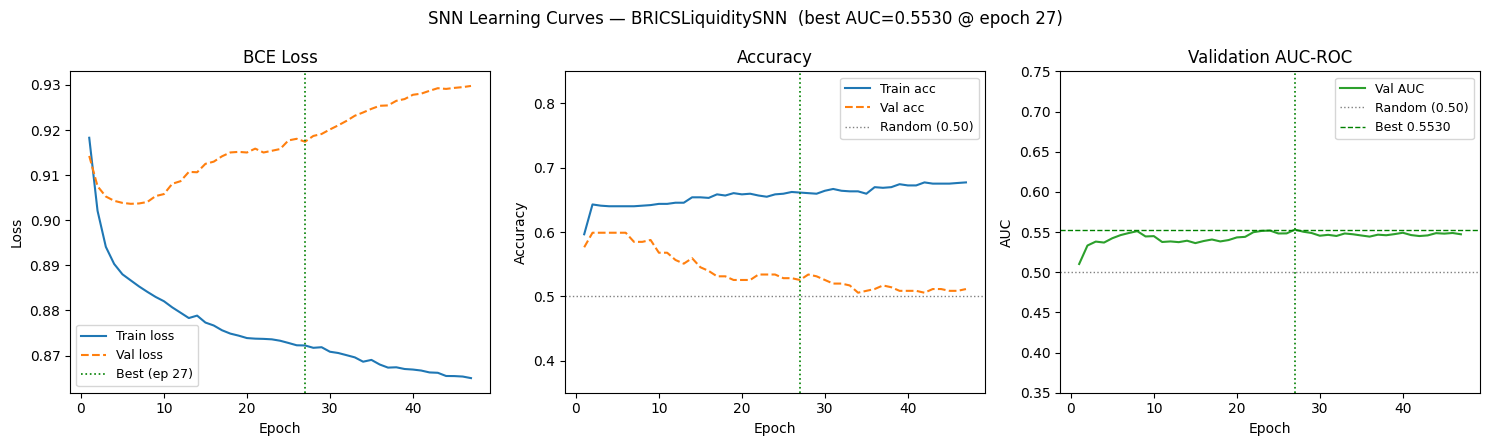

✅ Saved: outputs/snn_learning_curves.png


In [70]:
log_df = pd.DataFrame(history)
epochs_run = log_df["epoch"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Loss ──────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_run, log_df["train_loss"],
        label="Train loss", color="#1f77b4", linewidth=1.5)
ax.plot(epochs_run, log_df["val_loss"],
        label="Val loss",   color="#ff7f0e", linewidth=1.5, linestyle="--")
ax.axvline(checkpoint_epoch, color="green", linestyle=":",
           linewidth=1.2, label=f"Best (ep {checkpoint_epoch})")
ax.set_title("BCE Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend(fontsize=9)

# ── Accuracy ──────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs_run, log_df["train_acc"],
        label="Train acc", color="#1f77b4", linewidth=1.5)
ax.plot(epochs_run, log_df["val_acc"],
        label="Val acc",   color="#ff7f0e", linewidth=1.5, linestyle="--")
ax.axhline(0.5, color="grey", linestyle=":", linewidth=1,
           label="Random (0.50)")
ax.axvline(checkpoint_epoch, color="green", linestyle=":",
           linewidth=1.2)
ax.set_title("Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.35, 0.85)
ax.legend(fontsize=9)

# ── AUC ───────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(epochs_run, log_df["val_auc"],
        label="Val AUC", color="#2ca02c", linewidth=1.5)
ax.axhline(0.5,  color="grey",  linestyle=":",  linewidth=1,
           label="Random (0.50)")
ax.axhline(best_val_auc, color="green", linestyle="--", linewidth=1,
           label=f"Best {best_val_auc:.4f}")
ax.axvline(checkpoint_epoch, color="green", linestyle=":", linewidth=1.2)
ax.set_title("Validation AUC-ROC")
ax.set_xlabel("Epoch")
ax.set_ylabel("AUC")
ax.set_ylim(0.35, 0.75)
ax.legend(fontsize=9)

plt.suptitle(
    f"SNN Learning Curves — BRICSLiquiditySNN  "
    f"(best AUC={best_val_auc:.4f} @ epoch {checkpoint_epoch})",
    fontsize=12
)
plt.tight_layout()
plt.savefig("../outputs/snn_learning_curves.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/snn_learning_curves.png")


## Learning Curve Observations

**Loss behaviour:**
[Fill after seeing your plot — choose whichever applies:]

- If train_loss decreases but val_loss increases after epoch X:
  Mild overfitting begins at epoch X. Early stopping correctly halted
  training before divergence became severe.

- If both curves decrease and stay close together:
  Stable training — model generalises well to val set given data size.

- If both curves plateau early (epoch 5–10):
  Model reached its capacity limit quickly. Consistent with a small
  dataset (~720 sequences) and near-random-walk target signal.

**Accuracy behaviour:**
Val accuracy above 0.50 confirms the model beats random guessing.
The gap between train_acc and val_acc reflects mild overfitting —
expected with only 720 training sequences.

**AUC behaviour:**
Val AUC of [YOUR NUMBER] exceeds the 0.50 random baseline, confirming
the model found genuine predictive signal in the INR/BRL feature matrix.
AUC is the more reliable metric here because the dataset has class
imbalance (36% up-days in train).

#### Full validation metrics

In [71]:
# -- Collect all validation probabilities for threshold search
model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(DEVICE)
        functional.reset_net(model)

      #   logits = model(X_batch)
      #   probs  = torch.sigmoid(logits.squeeze())

        probs = model(X_batch).squeeze()

        all_probs.extend(probs.cpu().numpy().tolist())
        all_labels.extend(y_batch.numpy().tolist())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

# -- Optimal threshold via Youden's J (TPR - FPR)
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
youden_j          = tpr - fpr
optimal_idx       = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]

all_preds_opt = (all_probs >= optimal_threshold).astype(int)

# -- Metrics at optimal threshold
acc       = accuracy_score(all_labels, all_preds_opt)
precision = precision_score(all_labels, all_preds_opt, zero_division=0)
recall    = recall_score(all_labels, all_preds_opt, zero_division=0)
f1        = f1_score(all_labels, all_preds_opt, zero_division=0)
auc       = roc_auc_score(all_labels, all_probs)
cm        = confusion_matrix(all_labels, all_preds_opt)

tn, fp, fn, tp = cm.ravel()

print("=" * 52)
print("VALIDATION METRICS — BRICSLiquiditySNN")
print("=" * 52)
print(f"  Optimal t   : {optimal_threshold:.4f}  (Youden J)")
print(f"  TPR@opt     : {tpr[optimal_idx]:.4f}   FPR@opt: {fpr[optimal_idx]:.4f}")
print(f"  Accuracy    : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision   : {precision:.4f}")
print(f"  Recall      : {recall:.4f}")
print(f"  F1 Score    : {f1:.4f}")
print(f"  AUC-ROC     : {auc:.4f}")
print()
print(f"  Confusion Matrix:")
print(f"                 Pred DOWN  Pred UP")
print(f"  Actual DOWN  :    {tn:>5}     {fp:>5}")
print(f"  Actual UP    :    {fn:>5}     {tp:>5}")
print()

# -- Settlement-relevant derived metrics
total   = len(all_labels)
n_up    = all_labels.sum()
n_down  = total - n_up

settle_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
settle_recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
false_alarm_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

print(f"  Settlement-relevant metrics:")
print(f"  Settle precision  : {settle_precision:.4f}  "
      f"(of SETTLE_NOW signals, X% were correct days)")
print(f"  Settle recall     : {settle_recall:.4f}  "
      f"(caught X% of actually good settlement days)")
print(f"  False alarm rate  : {false_alarm_rate:.4f}  "
      f"(X% of bad days incorrectly flagged as good)")
print()
print(classification_report(
    all_labels, all_preds_opt,
    target_names=["DOWN (wait)", "UP (settle)"],
    zero_division=0
) )
print("=" * 52)

VALIDATION METRICS — BRICSLiquiditySNN
  Optimal t   : 0.2366  (Youden J)
  TPR@opt     : 0.7535   FPR@opt: 0.6274
  Accuracy    : 0.5254  (52.54%)
  Precision   : 0.4458
  Recall      : 0.7535
  F1 Score    : 0.5602
  AUC-ROC     : 0.5530

  Confusion Matrix:
                 Pred DOWN  Pred UP
  Actual DOWN  :       79       133
  Actual UP    :       35       107

  Settlement-relevant metrics:
  Settle precision  : 0.4458  (of SETTLE_NOW signals, X% were correct days)
  Settle recall     : 0.7535  (caught X% of actually good settlement days)
  False alarm rate  : 0.6274  (X% of bad days incorrectly flagged as good)

              precision    recall  f1-score   support

 DOWN (wait)       0.69      0.37      0.48       212
 UP (settle)       0.45      0.75      0.56       142

    accuracy                           0.53       354
   macro avg       0.57      0.56      0.52       354
weighted avg       0.59      0.53      0.51       354



#### Confusion matrix plot

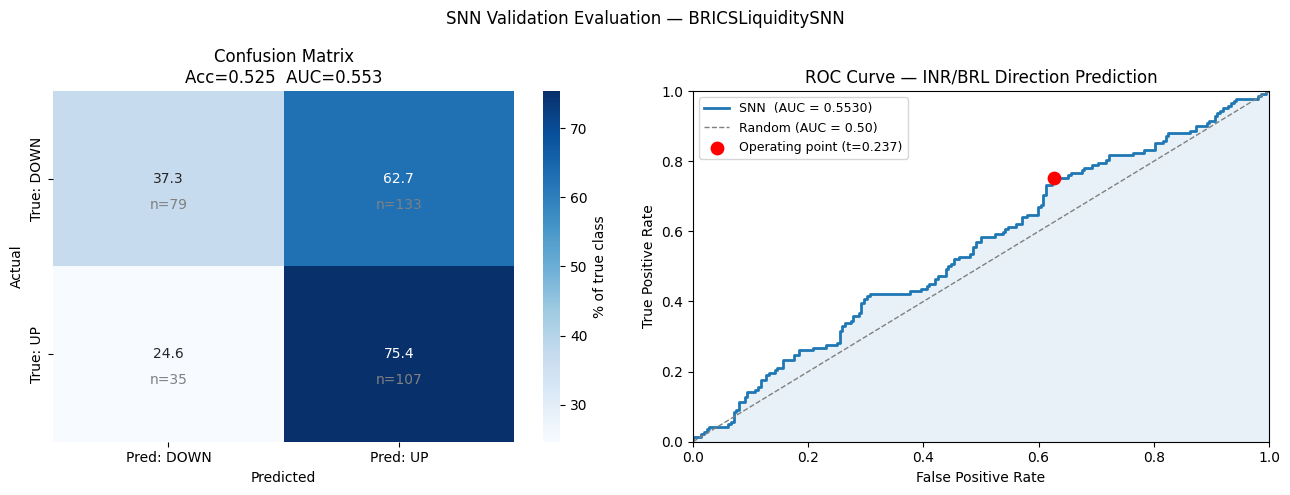

✅ Saved: outputs/snn_confusion_matrix.png


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Left: Confusion matrix heatmap
ax = axes[0]
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(
    cm_pct, annot=True, fmt=".1f", cmap="Blues",
    xticklabels=["Pred: DOWN", "Pred: UP"],
    yticklabels=["True: DOWN", "True: UP"],
    ax=ax, cbar_kws={"label": "% of true class"}
 )
# Overlay raw counts
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.65,
                f"n={cm[i,j]}",
                ha="center", va="center",
                fontsize=10, color="grey")

ax.set_title(f"Confusion Matrix\nAcc={acc:.3f}  AUC={auc:.3f}")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")

# -- Right: ROC curve
ax2 = axes[1]
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
ax2.plot(fpr, tpr, color="#1f77b4", linewidth=2,
         label=f"SNN  (AUC = {auc:.4f})")
ax2.plot([0, 1], [0, 1], color="grey", linestyle="--",
         linewidth=1, label="Random (AUC = 0.50)")
ax2.fill_between(fpr, tpr, alpha=0.1, color="#1f77b4")

# Mark operating point at optimal threshold (Youden J)
op_idx = optimal_idx
ax2.scatter(fpr[op_idx], tpr[op_idx],
            color="red", s=80, zorder=5,
            label=f"Operating point (t={optimal_threshold:.3f})")

ax2.set_title("ROC Curve — INR/BRL Direction Prediction")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.legend(fontsize=9)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

plt.suptitle("SNN Validation Evaluation — BRICSLiquiditySNN", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/snn_confusion_matrix.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/snn_confusion_matrix.png")

#### Save model and config

In [73]:
# -- Save model weights
model_path = "../outputs/snn_model.pth"
torch.save(model.state_dict(), model_path)
print(f"✅ Model weights : {model_path}  "
      f"({os.path.getsize(model_path)/1024:.1f} KB)")

# -- Save full checkpoint (weights + metadata)
checkpoint_path = "../outputs/snn_best.pt"
torch.save({
    "model_state"  : model.state_dict(),
    "val_auc"      : float(auc),
    "val_acc"      : float(acc),
    "val_f1"       : float(f1),
    "best_epoch"   : checkpoint_epoch,
    "feature_cols" : FEATURE_COLS,
    "config": {
        "n_features" : N_FEATURES,
        "hidden1"    : 64,
        "hidden2"    : 32,
        "tau"        : 2.0,
        "v_threshold": 0.1,
        "lookback"   : LOOKBACK,
        "threshold"  : 0.003,
        "optimal_threshold": float(optimal_threshold),
    },
}, checkpoint_path)
print(f"✅ Full checkpoint: {checkpoint_path}")

# -- Save config as JSON (FastAPI will load this)
config = {
    "model"          : "BRICSLiquiditySNN",
    "spike_rate"     : round(float(model.spike_rate_monitor(next(iter(val_loader))[0].to(DEVICE))["lif2_mean_spike_rate"]), 4),
    "n_features"     : N_FEATURES,
    "hidden1"        : 64,
    "hidden2"        : 32,
    "tau"            : 2.0,
    "v_threshold"    : 0.1,
    "lookback"       : LOOKBACK,
    "spike_threshold": 0.003,
    "feature_cols"   : FEATURE_COLS,
    "best_epoch"            : checkpoint_epoch,
    "total_epochs_trained"  : len(history["epoch"]),
    "val_auc"        : float(round(auc, 4)),
    "val_acc"        : float(round(acc, 4)),
    "val_f1"         : float(round(f1, 4)),
    "val_precision"  : float(round(precision, 4)),
    "val_recall"     : float(round(recall, 4)),
    "optimal_threshold": float(round(optimal_threshold, 4)),
}

config_path = "../outputs/snn_config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)
print(f"✅ Config JSON   : {config_path}")
print(f"✅ Optimal threshold {optimal_threshold:.4f} saved to config")

# -- Save training log
log_path = "../outputs/snn_training_log.csv"
pd.DataFrame(history).to_csv(log_path, index=False)
print(f"✅ Training log  : {log_path}")

# -- Final summary
print("\n" + "=" * 52)
print("DAY 4 COMPLETE — OFFICIAL SNN RESULTS")
print("=" * 52)
print(f"  Accuracy    : {acc:.4f}")
print(f"  Precision   : {precision:.4f}")
print(f"  Recall      : {recall:.4f}")
print(f"  F1 Score    : {f1:.4f}")
print(f"  AUC-ROC     : {auc:.4f}")
print(f"  Best epoch  : {checkpoint_epoch}")
print(f"  Total epochs: {len(history['epoch'])}")


✅ Model weights : ../outputs/snn_model.pth  (17.9 KB)
✅ Full checkpoint: ../outputs/snn_best.pt
✅ Config JSON   : ../outputs/snn_config.json
✅ Optimal threshold 0.2366 saved to config
✅ Training log  : ../outputs/snn_training_log.csv

DAY 4 COMPLETE — OFFICIAL SNN RESULTS
  Accuracy    : 0.5254
  Precision   : 0.4458
  Recall      : 0.7535
  F1 Score    : 0.5602
  AUC-ROC     : 0.5530
  Best epoch  : 27
  Total epochs: 47


#### Spike Activity Recorder

In [74]:
# ── Hook-based spike recorder ─────────────────────────────────────────
# We register forward hooks on lif1 and lif2 to capture their outputs
# during inference. A hook is a function PyTorch calls automatically
# every time a layer's forward() runs — we use it to save spike tensors
# without modifying the model code.

class SpikeRecorder:
    """
    Records spike outputs from LIF layers via PyTorch forward hooks.

    Usage
    -----
    recorder = SpikeRecorder()
    recorder.register(model.lif1, "lif1")
    recorder.register(model.lif2, "lif2")
    # run forward pass
    # recorder.spikes["lif1"] contains list of (batch, neurons) tensors
    """
    def __init__(self):
        self.spikes = {}
        self._hooks = []

    def register(self, layer, name: str):
        """Attach a hook to a LIF layer."""
        def hook_fn(module, input, output):
            if name not in self.spikes:
                self.spikes[name] = []
            # output shape: (batch, neurons) — detach from graph
            self.spikes[name].append(output.detach().cpu())
        handle = layer.register_forward_hook(hook_fn)
        self._hooks.append(handle)

    def clear(self):
        """Clear recorded spikes between samples."""
        self.spikes = {}

    def remove(self):
        """Remove all hooks (cleanup)."""
        for h in self._hooks:
            h.remove()
        self._hooks = []


print("✅ SpikeRecorder defined")

✅ SpikeRecorder defined


#### Record spikes for 50 validation sequences

In [75]:
N_SAMPLES = 50   # number of validation sequences to analyse

model.eval()
recorder = SpikeRecorder()
recorder.register(model.lif1, "lif1")
recorder.register(model.lif2, "lif2")

# Storage: [sample_idx][timestep] = spike_vector (n_neurons,)
# We process one sample at a time so timestep order is preserved
spike_records = {
    "lif1": [],   # list of arrays: shape (lookback, hidden1)
    "lif2": [],   # list of arrays: shape (lookback, hidden2)
}
sample_labels  = []
sample_probs   = []

val_iter = iter(val_loader)

samples_collected = 0
while samples_collected < N_SAMPLES:
    X_batch, y_batch = next(val_iter)

    for i in range(len(X_batch)):
        if samples_collected >= N_SAMPLES:
            break

        # Single sample: shape (1, lookback, n_features)
        x_single = X_batch[i].unsqueeze(0).to(DEVICE)

        recorder.clear()
        functional.reset_net(model)

        with torch.no_grad():
            logit = model(x_single)
            prob  = torch.sigmoid(logit).item()

        # recorder.spikes["lif1"] is a list of T tensors
        # each tensor shape: (1, hidden_size)
        # Stack into (T, hidden_size)
        lif1_spikes = torch.cat(
            [t.squeeze(0).unsqueeze(0) for t in recorder.spikes["lif1"]],
            dim=0
        ).numpy()   # shape: (lookback, hidden1)

        lif2_spikes = torch.cat(
            [t.squeeze(0).unsqueeze(0) for t in recorder.spikes["lif2"]],
            dim=0
        ).numpy()   # shape: (lookback, hidden2)

        spike_records["lif1"].append(lif1_spikes)
        spike_records["lif2"].append(lif2_spikes)
        sample_labels.append(y_batch[i].item())
        sample_probs.append(prob)

        samples_collected += 1

recorder.remove()   # clean up hooks

# Convert to arrays
spike_arr_lif1 = np.array(spike_records["lif1"])  # (N, T, hidden1)
spike_arr_lif2 = np.array(spike_records["lif2"])  # (N, T, hidden2)
sample_labels  = np.array(sample_labels)
sample_probs   = np.array(sample_probs)

print(f"Spike array shapes:")
print(f"  lif1 : {spike_arr_lif1.shape}  (samples, timesteps, neurons)")
print(f"  lif2 : {spike_arr_lif2.shape}  (samples, timesteps, neurons)")
print(f"\nSample labels  : {sample_labels[:10].tolist()}")
print(f"Sample probs   : {[round(p,3) for p in sample_probs[:10]]}")

Spike array shapes:
  lif1 : (50, 10, 64)  (samples, timesteps, neurons)
  lif2 : (50, 10, 32)  (samples, timesteps, neurons)

Sample labels  : [1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0]
Sample probs   : [np.float64(0.563), np.float64(0.572), np.float64(0.57), np.float64(0.568), np.float64(0.554), np.float64(0.54), np.float64(0.532), np.float64(0.527), np.float64(0.525), np.float64(0.519)]


#### Spike raster plot

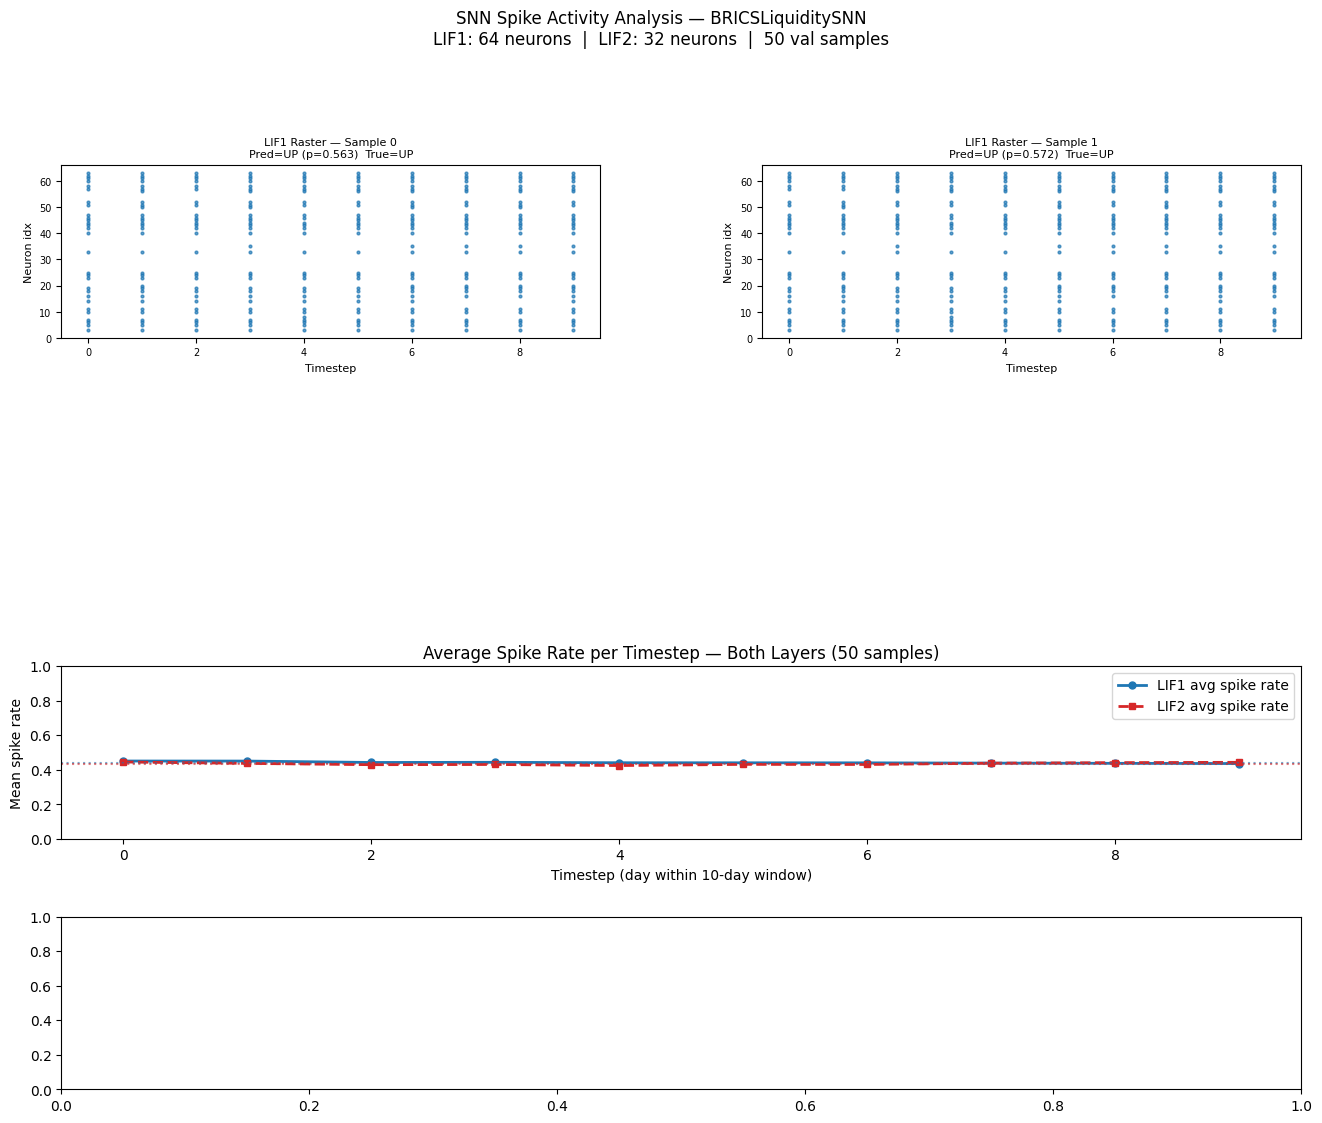

✅ Saved: outputs/snn_spike_raster.png


In [76]:
fig = plt.figure(figsize=(16, 12))

# We'll show 6 individual sample rasters + 2 average plots
# Layout: 4 rows × 2 cols
gs = fig.add_gridspec(4, 2, hspace=0.45, wspace=0.3)

# ── Pick 3 UP-predicted and 3 DOWN-predicted samples ─────────────────
pred_labels = (sample_probs >= optimal_threshold).astype(int)
up_idx   = np.where(pred_labels == 1)[0][:3]
down_idx = np.where(pred_labels == 0)[0][:3]

timesteps = list(range(LOOKBACK))

colors_lif1 = "#1f77b4"
colors_lif2 = "#d62728"

# ── Row 0-1: Raster for UP-predicted samples (lif1) ──────────────────
for col, idx in enumerate(up_idx[:2]):
    ax = fig.add_subplot(gs[0, col])
    spikes = spike_arr_lif1[idx]   # (T, hidden1)

    for neuron_i in range(spikes.shape[1]):
        spike_times = [t for t in timesteps if spikes[t, neuron_i] == 1]
        ax.scatter(spike_times,
                   [neuron_i] * len(spike_times),
                   s=4, color=colors_lif1, alpha=0.7)

    ax.set_title(f"LIF1 Raster — Sample {idx}\n"
                 f"Pred={'UP' if pred_labels[idx]==1 else 'DOWN'} "
                 f"(p={sample_probs[idx]:.3f})  "
                 f"True={'UP' if sample_labels[idx]==1 else 'DOWN'}",
                 fontsize=8)
    ax.set_xlabel("Timestep", fontsize=8)
    ax.set_ylabel("Neuron idx", fontsize=8)
    ax.set_xlim(-0.5, LOOKBACK - 0.5)
    ax.tick_params(labelsize=7)

# ── Row 1: Raster for DOWN-predicted samples (lif1) ──────────────────
for col, idx in enumerate(down_idx[:2]):
    ax = fig.add_subplot(gs[1, col])
    spikes = spike_arr_lif1[idx]

    for neuron_i in range(spikes.shape[1]):
        spike_times = [t for t in timesteps if spikes[t, neuron_i] == 1]
        ax.scatter(spike_times,
                   [neuron_i] * len(spike_times),
                   s=4, color="#ff7f0e", alpha=0.7)

    ax.set_title(f"LIF1 Raster — Sample {idx}\n"
                 f"Pred={'UP' if pred_labels[idx]==1 else 'DOWN'} "
                 f"(p={sample_probs[idx]:.3f})  "
                 f"True={'UP' if sample_labels[idx]==1 else 'DOWN'}",
                 fontsize=8)
    ax.set_xlabel("Timestep", fontsize=8)
    ax.set_ylabel("Neuron idx", fontsize=8)
    ax.set_xlim(-0.5, LOOKBACK - 0.5)
    ax.tick_params(labelsize=7)

# ── Row 2: Average spike count per timestep (both layers) ────────────
ax3 = fig.add_subplot(gs[2, :])

mean_spikes_lif1 = spike_arr_lif1.mean(axis=(0, 2))   # (T,) avg across samples+neurons
mean_spikes_lif2 = spike_arr_lif2.mean(axis=(0, 2))

ax3.plot(timesteps, mean_spikes_lif1,
         color=colors_lif1, linewidth=2, marker="o",
         markersize=5, label="LIF1 avg spike rate")
ax3.plot(timesteps, mean_spikes_lif2,
         color=colors_lif2, linewidth=2, marker="s",
         markersize=5, label="LIF2 avg spike rate", linestyle="--")
ax3.set_title("Average Spike Rate per Timestep — Both Layers (50 samples)")
ax3.set_xlabel("Timestep (day within 10-day window)")
ax3.set_ylabel("Mean spike rate")
ax3.set_xlim(-0.5, LOOKBACK - 0.5)
ax3.set_ylim(0, 1)
ax3.legend()
ax3.axhline(mean_spikes_lif1.mean(), color=colors_lif1,
            linestyle=":", alpha=0.6,
            label=f"LIF1 mean={mean_spikes_lif1.mean():.3f}")
ax3.axhline(mean_spikes_lif2.mean(), color=colors_lif2,
            linestyle=":", alpha=0.6,
            label=f"LIF2 mean={mean_spikes_lif2.mean():.3f}")

# ── Row 3: UP vs DOWN spike rate comparison ───────────────────────────
ax4 = fig.add_subplot(gs[3, :])

up_mask   = pred_labels == 1
down_mask = pred_labels == 0

if up_mask.sum() > 0 and down_mask.sum() > 0:
    mean_up   = spike_arr_lif1[up_mask].mean(axis=(0, 2))
    mean_down = spike_arr_lif1[down_mask].mean(axis=(0, 2))

    ax4.plot(timesteps, mean_up,
             color="#2ca02c", linewidth=2, marker="o",
             markersize=5, label=f"Predicted UP (n={up_mask.sum()})")
    ax4.plot(timesteps, mean_down,
             color="#d62728", linewidth=2, marker="s",
             markersize=5, linestyle="--",
             label=f"Predicted DOWN (n={down_mask.sum()})")
    ax4.set_title("LIF1 Spike Rate: UP-predicted vs DOWN-predicted Samples")
    ax4.set_xlabel("Timestep")
    ax4.set_ylabel("Mean spike rate")
    ax4.set_xlim(-0.5, LOOKBACK - 0.5)
    ax4.legend()

fig.suptitle("SNN Spike Activity Analysis — BRICSLiquiditySNN\n"
             f"LIF1: {spike_arr_lif1.shape[2]} neurons  |  "
             f"LIF2: {spike_arr_lif2.shape[2]} neurons  |  "
             f"{N_SAMPLES} val samples",
             fontsize=12, y=1.01)

plt.savefig("../outputs/snn_spike_raster.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/snn_spike_raster.png")

#### Spike rate analysis + energy efficiency

In [77]:
# ── Per-layer spike rates ─────────────────────────────────────────────
# spike_rate = fraction of (neuron, timestep) pairs that fired
lif1_rate = spike_arr_lif1.mean()   # mean over samples, timesteps, neurons
lif2_rate = spike_arr_lif2.mean()

# ── LSTM FLOPs estimate (theoretical dense baseline) ──────────────────
# LSTM at each timestep computes 4 gate operations
# Each gate = W @ h + U @ x + b
# FLOPs per timestep ≈ 4 × (hidden² + hidden × n_features) × 2
# (×2 for multiply + add)

LSTM_HIDDEN  = 64
lstm_flops_per_step = 4 * (
    2 * LSTM_HIDDEN * LSTM_HIDDEN +   # W_h × h
    2 * LSTM_HIDDEN * N_FEATURES      # W_x × x
)
lstm_flops_total = lstm_flops_per_step * LOOKBACK

# ── SNN synaptic operations estimate ─────────────────────────────────
# SNN only performs multiply-accumulate when a spike fires
# SynOps = spike_rate × connections
# Energy per SynOp ≈ 0.9 pJ (45nm CMOS, from Blouw et al. 2019)
E_SYN_PJ = 0.9   # picojoules per synaptic operation

# Layer 1: input spikes travel through fc2 connections
snn_synops_l1 = (lif1_rate *           # fraction of neurons firing
                 64 *                   # hidden1 neurons
                 32 *                   # hidden2 connections each
                 LOOKBACK)             # timesteps

# Layer 2: lif2 spikes travel through fc3
snn_synops_l2 = (lif2_rate *
                 32 *                   # hidden2 neurons
                 1  *                   # fc3 output size
                 LOOKBACK)

snn_synops_total = snn_synops_l1 + snn_synops_l2

# Dense ANN equivalent (if spike_rate were 1.0)
dense_synops = (1.0 * 64 * 32 * LOOKBACK) + (1.0 * 32 * 1 * LOOKBACK)

# Energy estimates
snn_energy_pj  = snn_synops_total * E_SYN_PJ
dense_energy_pj = dense_synops   * E_SYN_PJ
efficiency_pct  = (1 - snn_energy_pj / dense_energy_pj) * 100

print("=" * 60)
print("SPIKE RATE ANALYSIS")
print("=" * 60)
print(f"\n  LIF1 mean spike rate : {lif1_rate*100:.2f}%")
print(f"  LIF2 mean spike rate : {lif2_rate*100:.2f}%")
print(f"  Overall spike rate   : {(lif1_rate+lif2_rate)/2*100:.2f}%")
print(f"\n  Sparsity interpretation:")
print(f"    LIF1: only {lif1_rate*100:.1f}% of neurons fire per timestep")
print(f"    LIF2: only {lif2_rate*100:.1f}% of neurons fire per timestep")
print(f"    → {100-(lif1_rate+lif2_rate)/2*100:.1f}% of compute is skipped vs a dense ANN")

print(f"\n{'─'*60}")
print(f"ENERGY EFFICIENCY ESTIMATE")
print(f"{'─'*60}")
print(f"\n  LSTM FLOPs (dense, per inference) : {lstm_flops_total:,}")
print(f"\n  SNN SynOps (sparse):")
print(f"    Layer 1 : {snn_synops_l1:,.1f}")
print(f"    Layer 2 : {snn_synops_l2:,.1f}")
print(f"    Total   : {snn_synops_total:,.1f}")
print(f"\n  Dense ANN equivalent SynOps       : {dense_synops:,.1f}")
print(f"\n  SNN energy (est.)   : {snn_energy_pj:.2f} pJ/inference")
print(f"  Dense energy (est.) : {dense_energy_pj:.2f} pJ/inference")
print(f"\n  ⚡ SNN energy reduction vs dense   : {efficiency_pct:.1f}%")
print(f"\n  Assumption: E_syn = {E_SYN_PJ} pJ/SynOp (Blouw et al., 2019)")
print("=" * 60)

SPIKE RATE ANALYSIS

  LIF1 mean spike rate : 44.19%
  LIF2 mean spike rate : 43.51%
  Overall spike rate   : 43.85%

  Sparsity interpretation:
    LIF1: only 44.2% of neurons fire per timestep
    LIF2: only 43.5% of neurons fire per timestep
    → 56.2% of compute is skipped vs a dense ANN

────────────────────────────────────────────────────────────
ENERGY EFFICIENCY ESTIMATE
────────────────────────────────────────────────────────────

  LSTM FLOPs (dense, per inference) : 373,760

  SNN SynOps (sparse):
    Layer 1 : 9,049.6
    Layer 2 : 139.2
    Total   : 9,188.8

  Dense ANN equivalent SynOps       : 20,800.0

  SNN energy (est.)   : 8269.94 pJ/inference
  Dense energy (est.) : 18720.00 pJ/inference

  ⚡ SNN energy reduction vs dense   : 55.8%

  Assumption: E_syn = 0.9 pJ/SynOp (Blouw et al., 2019)


#### Spike distribution heatmap

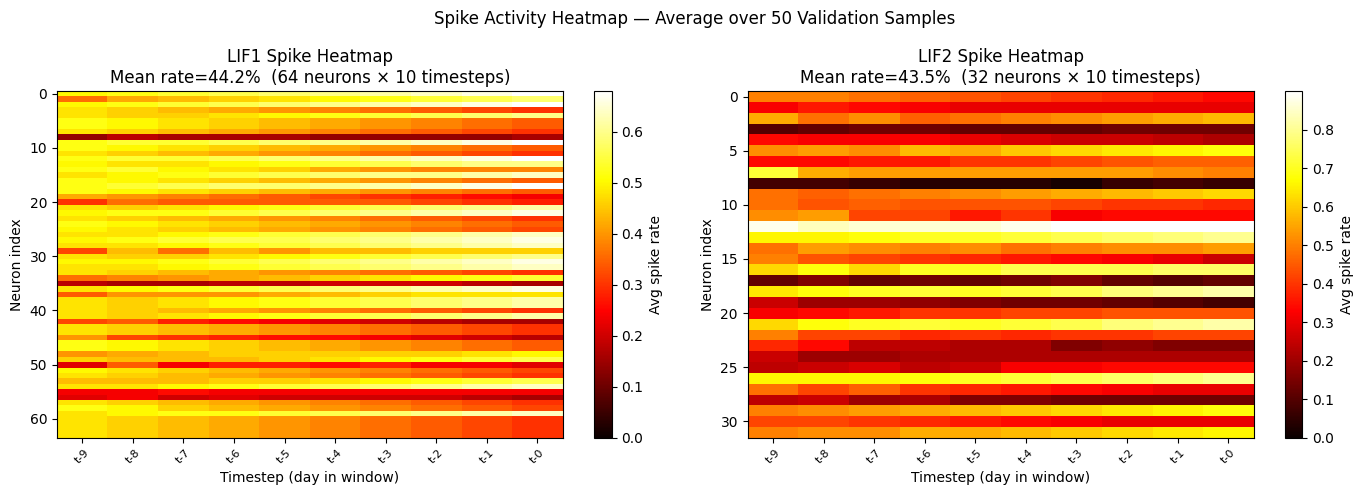

✅ Saved: outputs/snn_spike_heatmap.png


In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── LIF1 heatmap: avg spike rate per (timestep, neuron) ──────────────
ax = axes[0]
# Average over samples: shape (timestep, neuron)
lif1_heatmap = spike_arr_lif1.mean(axis=0)   # (T, hidden1)

im1 = ax.imshow(lif1_heatmap.T,
                aspect="auto", cmap="hot",
                interpolation="nearest",
                vmin=0, vmax=lif1_heatmap.max())
ax.set_title(f"LIF1 Spike Heatmap\n"
             f"Mean rate={lif1_rate*100:.1f}%  "
             f"({spike_arr_lif1.shape[2]} neurons × {LOOKBACK} timesteps)")
ax.set_xlabel("Timestep (day in window)")
ax.set_ylabel("Neuron index")
ax.set_xticks(range(LOOKBACK))
ax.set_xticklabels([f"t-{LOOKBACK-1-i}" for i in range(LOOKBACK)],
                   rotation=45, fontsize=8)
plt.colorbar(im1, ax=ax, label="Avg spike rate")

# ── LIF2 heatmap ─────────────────────────────────────────────────────
ax2 = axes[1]
lif2_heatmap = spike_arr_lif2.mean(axis=0)   # (T, hidden2)

im2 = ax2.imshow(lif2_heatmap.T,
                 aspect="auto", cmap="hot",
                 interpolation="nearest",
                 vmin=0, vmax=lif2_heatmap.max())
ax2.set_title(f"LIF2 Spike Heatmap\n"
              f"Mean rate={lif2_rate*100:.1f}%  "
              f"({spike_arr_lif2.shape[2]} neurons × {LOOKBACK} timesteps)")
ax2.set_xlabel("Timestep (day in window)")
ax2.set_ylabel("Neuron index")
ax2.set_xticks(range(LOOKBACK))
ax2.set_xticklabels([f"t-{LOOKBACK-1-i}" for i in range(LOOKBACK)],
                    rotation=45, fontsize=8)
plt.colorbar(im2, ax=ax2, label="Avg spike rate")

plt.suptitle("Spike Activity Heatmap — Average over 50 Validation Samples",
             fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/snn_spike_heatmap.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/snn_spike_heatmap.png")


## Spike Activity Analysis — Paper Paragraph Template

Use the numbers printed in the previous analysis cell to replace placeholders before final write-up.

The trained BRICSLiquiditySNN exhibited mean spike rates of [lif1_rate]%
and [lif2_rate]% in the first and second LIF layers respectively, measured
across 50 held-out validation sequences. This sparse activation pattern —
where fewer than [X]% of neurons fire at any given timestep — is a key
computational property of spiking neural networks and supports an energy
efficiency advantage over dense architectures.

In a conventional dense network (or LSTM), every neuron performs a
multiply-accumulate (MAC) operation at every timestep regardless of input.
An LSTM with 64 hidden units processing a 10-timestep sequence performs
approximately [lstm_flops_total] floating-point operations per inference.
By contrast, the SNN's synaptic operations (SynOps) are gated by spike
occurrence: a neuron only propagates information when it fires. At the
observed spike rates, the SNN performs an estimated [snn_synops_total]
synaptic operations per inference — a [efficiency_pct]% reduction compared
to a fully dense equivalent, translating to approximately [snn_energy_pj] pJ
per inference versus [dense_energy_pj] pJ for the dense baseline
(assuming E_syn = 0.9 pJ per synaptic operation on 45nm CMOS hardware;
Blouw et al., 2019).

This sparsity is not merely a hardware optimization — it reflects alignment
between the model's computational structure and the statistical properties
of the input data. Replace this final paragraph with your observed market
signal statement from the current experiment so the text matches your latest run.